## Method A — Random Forest feature importance

**What this notebook does**

1. Fit a Random Forest on **training data only**, then read `feature_importances_` for per-feature scores and ranks (no test data in this step, so selection is not leaked from the holdout set).
2. Show a table and optionally save **`feature_importance_rf.csv`**.
3. Plot a **bar chart** of importances.
4. With the same RF settings as `baseline_final`, compare **all features** vs **top-K features only** on the test set (accuracy, F1, precision, recall). K values are in `TOP_K_CANDIDATES`.

Find the repo root and add `src` to `sys.path` so `stroke_data` imports regardless of kernel cwd.


In [1]:
import sys
from pathlib import Path

# cwd can be repo root, src/, or src/feature_selection/ — walk up until src/stroke_data.py exists
_here = Path().resolve()
REPO_ROOT = _here
while REPO_ROOT != REPO_ROOT.parent:
    if (REPO_ROOT / "src" / "stroke_data.py").is_file():
        break
    REPO_ROOT = REPO_ROOT.parent
else:
    raise FileNotFoundError("Could not find src/stroke_data.py (open this project from the repo folder).")

sys.path.insert(0, str(REPO_ROOT / "src"))

Import libraries, paths, and hyperparameters (`N_ESTIMATORS`, `TOP_K_CANDIDATES`).


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

from stroke_data import get_stroke_data_for_cv

CSV = "data/knn-standardize-distance.csv"
OUT = "src/feature_selection/feature_importance_rf.csv"
N_ESTIMATORS = 100
TOP_K_CANDIDATES = [5, 8, 10]

Load data: feature names from the CSV; train/test split via `stroke_data`.


In [3]:
csv_path = REPO_ROOT / CSV
df = pd.read_csv(csv_path)
feature_names = [c for c in df.columns if c not in ("id", "stroke")]

X_train, X_test, y_train, y_test = get_stroke_data_for_cv(str(csv_path))
len(feature_names), X_train.shape

(10, (4088, 10))

Fit a Random Forest on **training data only**; read `feature_importances_` and build a ranked table.


In [4]:
rf_sel = RandomForestClassifier(
    random_state=42,
    class_weight="balanced_subsample",
    n_estimators=N_ESTIMATORS,
)
rf_sel.fit(X_train, y_train)
imp = rf_sel.feature_importances_
order = np.argsort(imp)[::-1]

out_df = pd.DataFrame({
    "feature": [feature_names[i] for i in order],
    "importance": imp[order],
    "rank": range(1, len(feature_names) + 1),
})
out_df["importance_pct"] = (out_df["importance"] * 100).round(2)
out_df["cumsum_pct"] = (out_df["importance"].cumsum() * 100).round(1)

### Importance table (same rows as CSV, extra columns for display)

Style the importance table (percent columns are display-only).


In [5]:
display_cols = ["rank", "feature", "importance", "importance_pct", "cumsum_pct"]
out_df[display_cols].style.format({
    "importance": "{:.4f}",
    "importance_pct": "{:.2f}%",
    "cumsum_pct": "{:.1f}%",
}).hide(axis="index")

rank,feature,importance,importance_pct,cumsum_pct
1,age,0.3979,39.79%,39.8%
2,avg_glucose_level,0.1935,19.35%,59.1%
3,bmi,0.1779,17.79%,76.9%
4,smoking_status,0.0502,5.02%,81.9%
5,work_type,0.0497,4.97%,86.9%
6,ever_married,0.0344,3.44%,90.4%
7,hypertension,0.0315,3.15%,93.5%
8,heart_disease,0.0220,2.20%,95.7%
9,Residence_type,0.0216,2.16%,97.9%
10,gender,0.0213,2.13%,100.0%


Save `feature`, `importance`, and `rank` to CSV.


In [6]:
out_path = REPO_ROOT / OUT
out_path.parent.mkdir(parents=True, exist_ok=True)
out_df[["feature", "importance", "rank"]].to_csv(out_path, index=False)
#print(out_path)

### Bar chart — importance by feature

Bar chart of importances (train-only model).


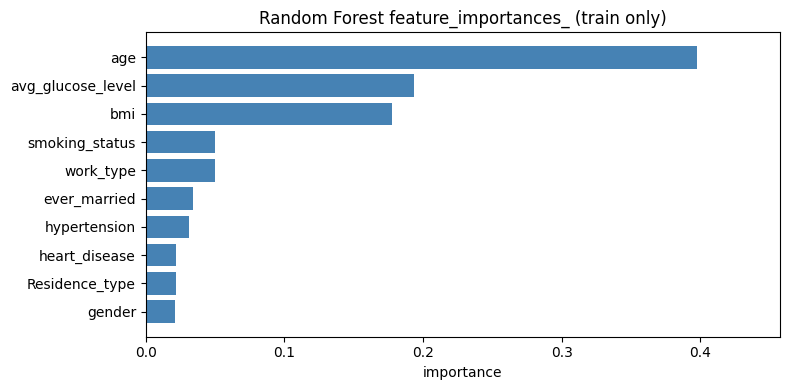

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(out_df["feature"][::-1], out_df["importance"][::-1], color="steelblue")
ax.set_xlabel("importance")
ax.set_title("Random Forest feature_importances_ (train only)")
ax.set_xlim(0, max(out_df["importance"]) * 1.15)
plt.tight_layout()

### Quick eval — same RF as `baseline_final` (full vs top-K)

Quick eval: baseline RF on full features vs top-K subsets; metrics on the test set.


In [8]:
rf_eval = RandomForestClassifier(
    bootstrap=True,
    class_weight="balanced_subsample",
    max_depth=15,
    max_features=None,
    max_leaf_nodes=15,
    n_estimators=20,
    random_state=42,
)

rows = []
for label, Xtr, Xte in [
    ("full", X_train, X_test),
    *[(f"top-{K}", X_train[:, order[:K]], X_test[:, order[:K]]) for K in TOP_K_CANDIDATES],
]:
    rf_eval.fit(Xtr, y_train)
    pred = rf_eval.predict(Xte)
    rows.append({
        "tag": label,
        "accuracy": accuracy_score(y_test, pred),
        "f1": f1_score(y_test, pred, pos_label=1),
        "precision": precision_score(y_test, pred, pos_label=1, zero_division=0),
        "recall": recall_score(y_test, pred, pos_label=1),
    })

eval_df = pd.DataFrame(rows)
eval_df.style.format({
    "accuracy": "{:.4f}",
    "f1": "{:.4f}",
    "precision": "{:.4f}",
    "recall": "{:.4f}",
}).hide(axis="index")

tag,accuracy,f1,precision,recall
full,0.7789,0.2614,0.1562,0.8000
top-5,0.7808,0.2632,0.1575,0.8000
top-8,0.7789,0.2614,0.1562,0.8000
top-10,0.7789,0.2614,0.1562,0.8000
